# movement_decompose_2d running example
Welcome! This file is an example on how to work with this library, and decompose a single 2d movement into probable submovements that compose it. \
The first step is always to import the relevant module:

In [1]:
import movement_decompose_2d

### load data

In [19]:
example_data = r'../data/subject08day1post'
position_filtered, velocity, time = movement_decompose_2d.load_data(example_data)

### Display movements

#### Movement Position

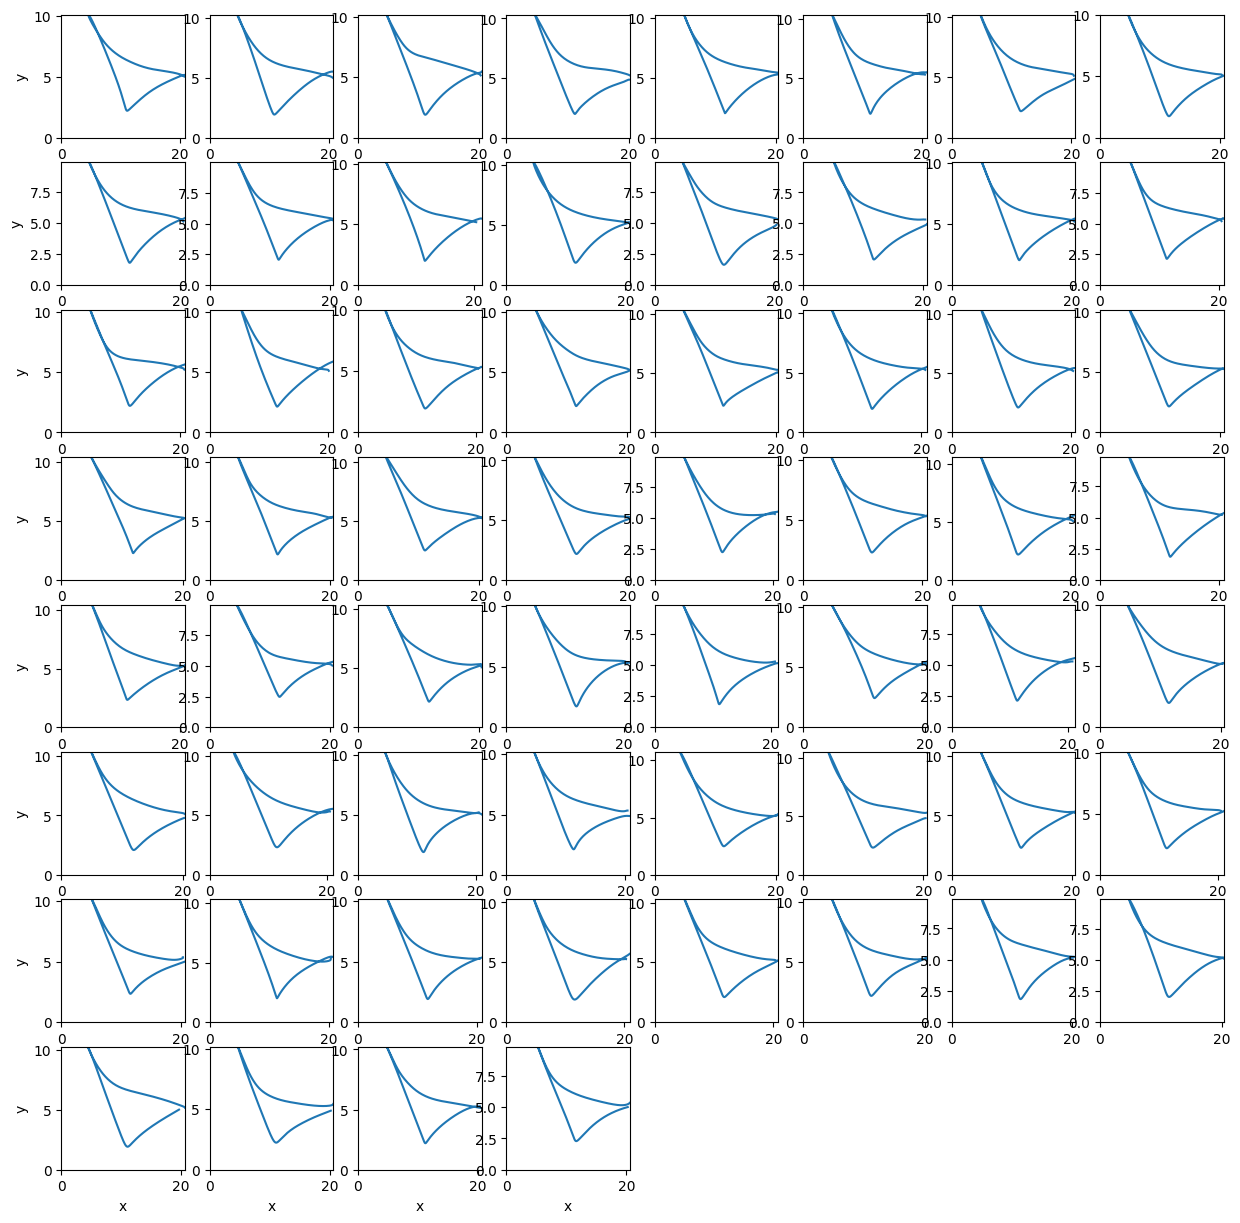

In [20]:
movement_decompose_2d.plot_position(position_filtered, time,plot_type=1) #  x vs y position

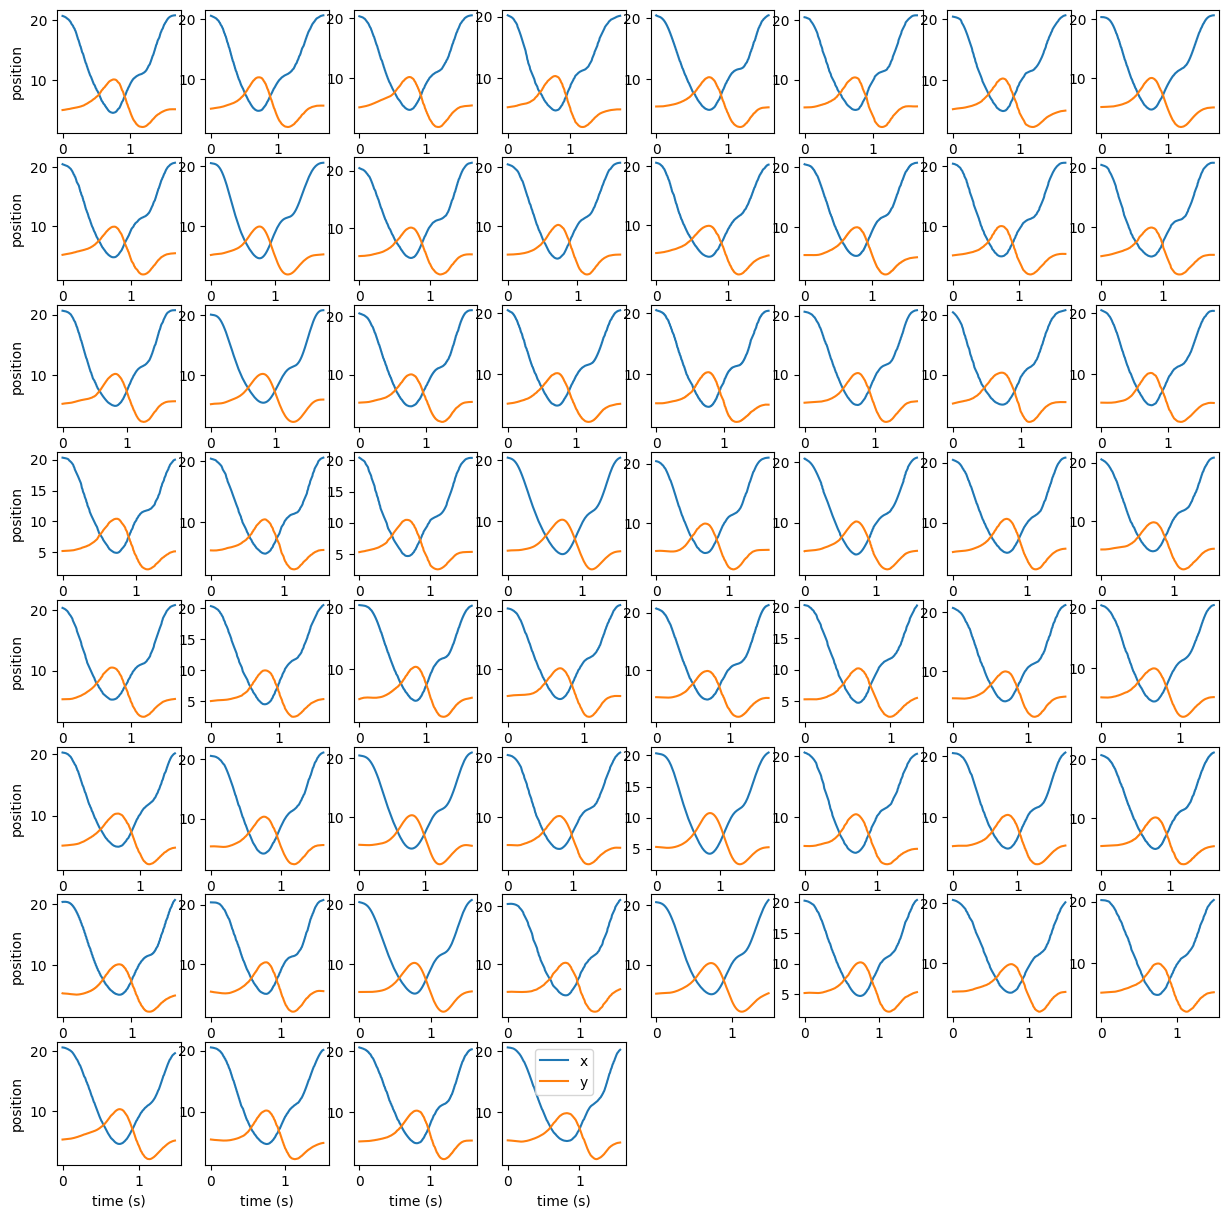

In [21]:
movement_decompose_2d.plot_position(position_filtered, time,plot_type=2) # Time vs. x & y position.

#### Movement Velocity

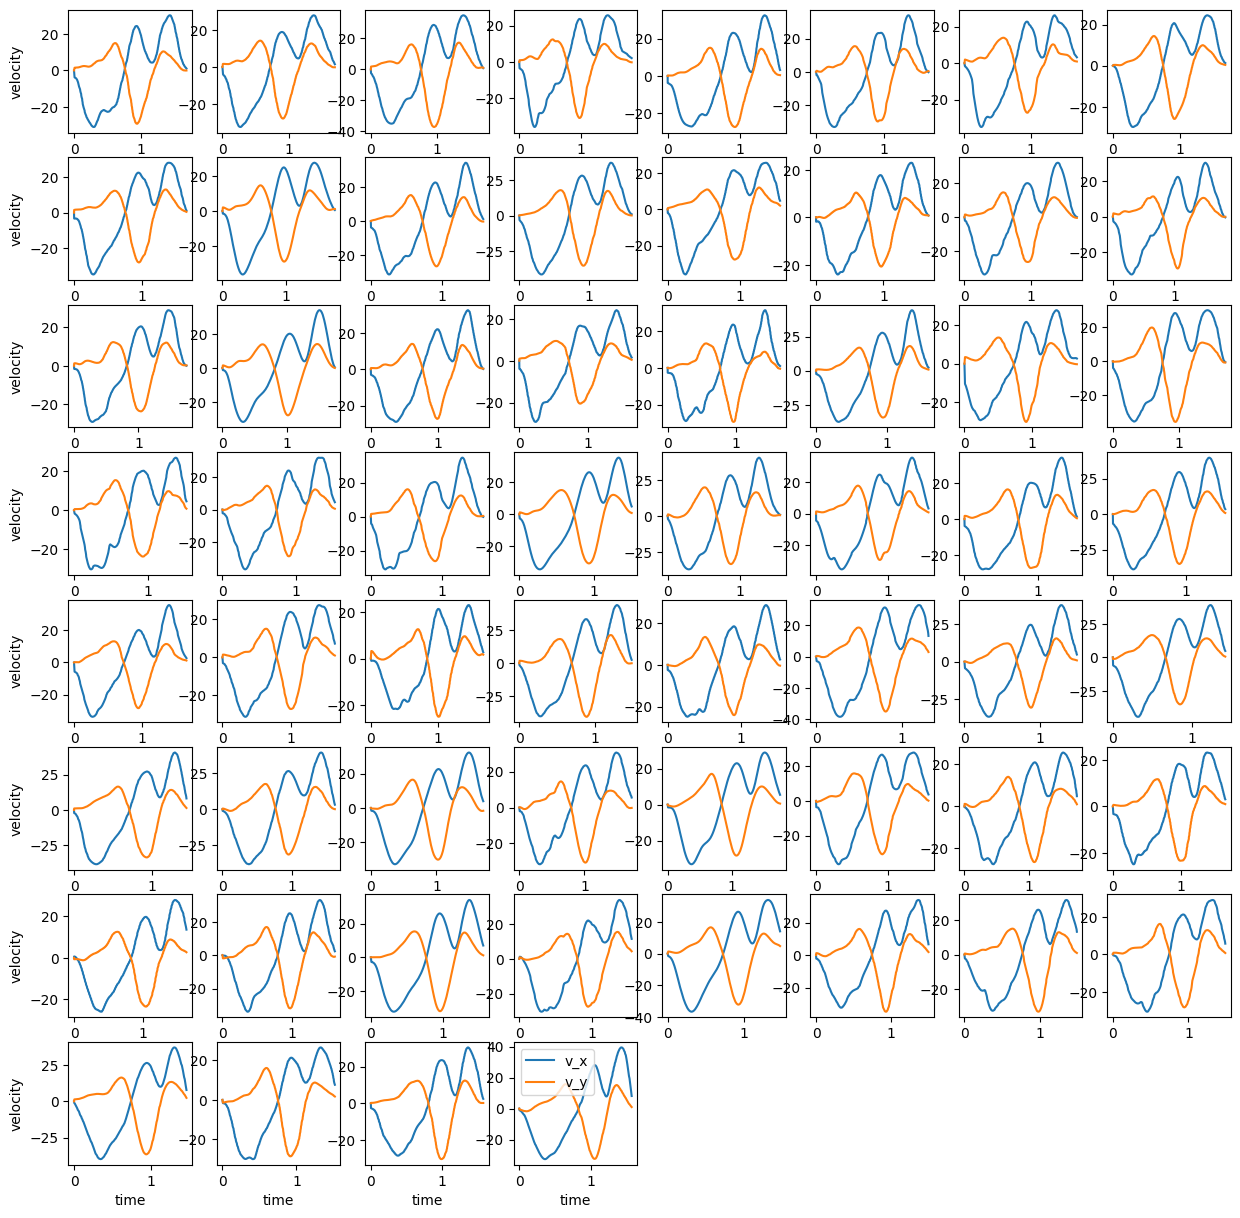

In [22]:
movement_decompose_2d.plot_velocity(velocity, time,plot_type=1) # Time vs. v_x & v_y velocity.

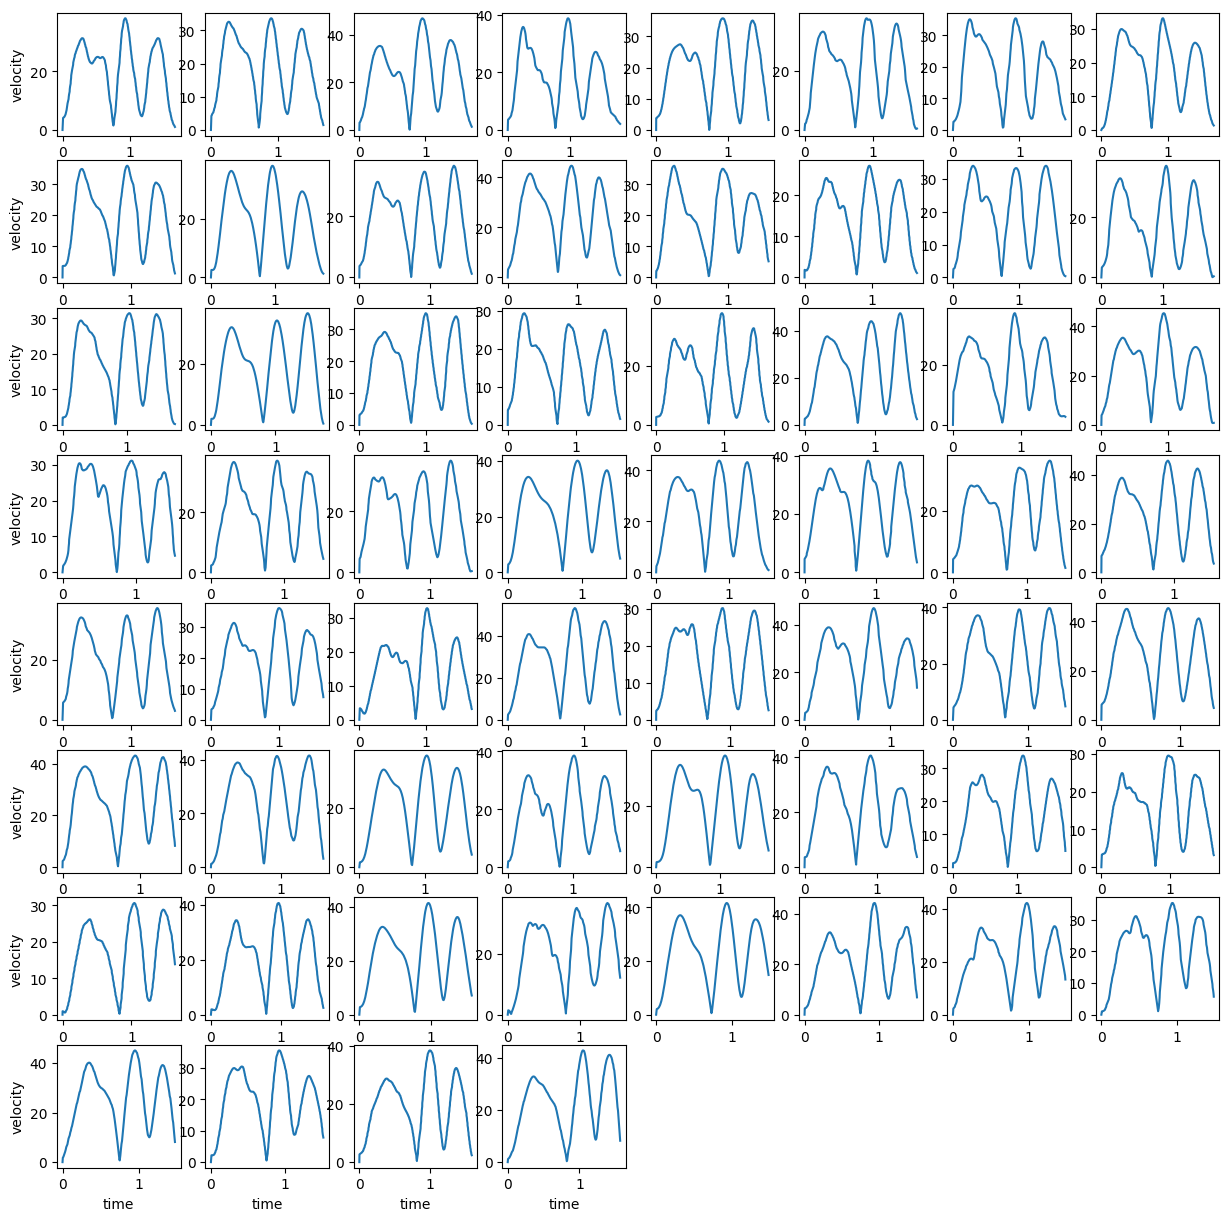

In [23]:
movement_decompose_2d.plot_velocity(velocity, time,plot_type=2) # Time vs. tangential velocity.

### Decompose to 4 submovments

In [24]:
# define parameters: , what is the & y
n_submovements = 4 # how many submovments
x_range = (-20, 20) #  minimal & maximal values of x
y_range = (-10, 10) #  minimal & maximal values of y
mov_ind = 0 # movement to decompose, by ind

# decompose the movement. Note that we use the velocity, not the position
best_error, final_parms = movement_decompose_2d.decompose_2D(time[mov_ind], velocity[mov_ind],
                                      n_sub_movement=n_submovements,
                                      x_rng=x_range, y_rng=y_range)
print(best_error) # print the error of the found movement
print(final_parms) # print the parameters of the submovement.

0.1308831533753857
[[ 0.02179395  0.5019606  -7.91882695 -1.48298954]
 [ 0.34380214  0.44550112 -5.64322695  3.5712785 ]
 [ 0.73292668  0.34972564  2.43640457 -1.16709403]
 [ 0.74923156  0.44960694  2.55431915 -5.33093553]
 [ 1.11749614  0.56702563 10.11676287  0.05144775]
 [ 1.49657232  0.94106474  6.98575538 -0.88139065]]


In final_parms, each row is a different submovment, and each col is a different parameter.\
The parameters are (by column order):\
 [start_t, movment_duration, displacement_x, displacement_y].

### Plot submovements & actual velocities

In [25]:
import matplotlib.pyplot as plt # just for adding the actual movement
import numpy as np
axs,_,vx_lines,vy_lines,vx_sum_line,vy_sum_line = movement_decompose_2d.plot_submovements_2D(final_parms,t=time[mov_ind])
vel_x = velocity[mov_ind][:,0]
vel_y = velocity[mov_ind][:,1]
line_true_v_x = axs[0].plot(time[mov_ind],vel_x,'k', label='true velocity')
line_true_v_y = axs[1].plot(time[mov_ind],vel_y,'k', label='true velocity')
axs[0].legend(handles=[vx_lines[0], vx_sum_line[0], line_true_v_x[0]])
axs[1].legend(handles=[vy_lines[0], vy_sum_line[0], line_true_v_y[0]])
plt.show()

# Show the submovement parameters extracted
import pandas as pd
data = pd.DataFrame(final_parms)
data.columns = ['t0','D','Ax','Ay'] 
data

ValueError: The parameters vector must have a length that is a multiple of 4

In [ ]:
pipreqsnb